In [2]:
# Pin to GPU 1 for this kernel session
import os, torch
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
# After setting the env var, the visible device index 0 maps to physical GPU 1
if torch.cuda.is_available():
    torch.cuda.set_device(0)
    print('CUDA pinned. Logical device 0 ->', torch.cuda.get_device_name(0))
else:
    print('CUDA not available; running on CPU')

CUDA pinned. Logical device 0 -> NVIDIA L40


# 0 - Imports & Settings

In [3]:
import os
import json
import time
import zipfile
import datetime
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from utils import *

Root directory is /astro/users/lindajin/WL_ML


# 1 - Helper Classes for
- Utitlity Functions
- Data Loading
- Visualizations
- Scoring Functions

### Utility

In [4]:
class Utility:
    @staticmethod
    def add_noise(data, mask, ng, pixel_size=2., std=None):
        """
        Add noise to a noiseless convergence map.

        Parameters
        ----------
        data : np.array
            Noiseless convergence maps (can be raw or normalized).
        mask : np.array
            Binary mask map.
        ng : float
            Number of galaxies per arcmin². This determines the noise level; a larger number means smaller noise.
        pixel_size : float, optional
            Pixel size in arcminutes (default is 2.0).
        std : float, optional
            If data is normalized, provide the std used for normalization.
            Noise scale will be adjusted accordingly.
            Note: mean centering doesn't affect noise since noise is zero-mean.
        """
        # Base noise in raw data units
        noise_raw = np.random.randn(*data.shape) * 0.4 / (2*ng*pixel_size**2)**0.5 * mask
        
        # If data is normalized, scale noise to match normalized units
        if std is not None:
            noise = noise_raw / std
        else:
            noise = noise_raw
            
        return data + noise
    
    @staticmethod
    def load_np(data_dir, file_name):
        file_path = os.path.join(data_dir, file_name)
        return np.load(file_path)

    @staticmethod
    def save_np(data_dir, file_name, data):
        file_path = os.path.join(data_dir, file_name)
        np.save(file_path, data)

    @staticmethod
    def save_json_zip(submission_dir, json_file_name, zip_file_name, data):
        """
        Save a dictionary with 'means' and 'errorbars' into a JSON file,
        then compress it into a ZIP file inside submission_dir.

        Parameters
        ----------
        submission_dir : str
            Path to the directory where the ZIP file will be saved.
        file_name : str
            Name of the ZIP file (without extension).
        data : dict
            Dictionary with keys 'means' and 'errorbars'.

        Returns
        -------
        str
            Path to the created ZIP file.
        """
        os.makedirs(submission_dir, exist_ok=True)

        json_path = os.path.join(submission_dir, json_file_name)

        # Save JSON file
        with open(json_path, "w") as f:
            json.dump(data, f)

        # Path to ZIP
        zip_path = os.path.join(submission_dir, zip_file_name)

        # Create ZIP containing only the JSON
        with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
            zf.write(json_path, arcname=json_file_name)

        # Remove the standalone JSON after zipping
        os.remove(json_path)

        return zip_path

### Data

In [5]:
class Data:
    def __init__(self, data_dir, USE_PUBLIC_DATASET):
        self.USE_PUBLIC_DATASET = USE_PUBLIC_DATASET
        self.data_dir = data_dir
        self.mask_file = 'WIDE12H_bin2_2arcmin_mask.npy'
        self.viz_label_file = 'label.npy'
        if self.USE_PUBLIC_DATASET:
            self.kappa_file = 'WIDE12H_bin2_2arcmin_kappa.npy'
            self.label_file = self.viz_label_file
            self.Ncosmo = 101  # Number of cosmologies in the entire training data
            self.Nsys = 256    # Number of systematic realizations in the entire training data
            self.test_kappa_file = 'WIDE12H_bin2_2arcmin_kappa_noisy_test.npy'
            self.Ntest = 4000  # Number of instances in the test data
        else:
            self.kappa_file = 'sampled_WIDE12H_bin2_2arcmin_kappa.npy'
            self.label_file = 'sampled_label.npy'
            self.Ncosmo = 3    # Number of cosmologies in the sampled training data
            self.Nsys = 30     # Number of systematic realizations in the sampled training data
            self.test_kappa_file = 'sampled_WIDE12H_bin2_2arcmin_kappa_noisy_test.npy'
            self.Ntest = 3     # Number of instances in the sampled test data
        
        self.shape = [1424,176] # dimensions of each map 
        self.pixelsize_arcmin = 2 # pixel size in arcmin
        self.pixelsize_radian = self.pixelsize_arcmin / 60 / 180 * np.pi # pixel size in radian
        self.ng = 30  # galaxy number density. This determines the noise level of the experiment. Do not change this number.

    def load_train_data(self):
        self.mask = Utility.load_np(data_dir=self.data_dir, file_name=self.mask_file) # A binary map that shows which parts of the sky are observed and which areas are blocked
        self.kappa = np.zeros((self.Ncosmo, self.Nsys, *self.shape), dtype=np.float16)
        self.kappa[:,:,self.mask] = Utility.load_np(data_dir=self.data_dir, file_name=self.kappa_file) # Training convergence maps
        self.label = Utility.load_np(data_dir=self.data_dir, file_name=self.label_file) # Training labels (cosmological and physical paramameters) of each training map
        self.viz_label = Utility.load_np(data_dir=self.data_dir, file_name=self.viz_label_file) # For visualization of parameter distributions

    def load_test_data(self):
        self.kappa_test = np.zeros((self.Ntest, *self.shape), dtype=np.float16)
        self.kappa_test[:,self.mask] = Utility.load_np(data_dir=self.data_dir, file_name=self.test_kappa_file) # Test noisy convergence maps

### Visualization

In [6]:
class Visualization:
    
    @staticmethod
    def plot_mask(mask):
        plt.figure(figsize=(30,100))
        plt.imshow(mask.T)
        plt.show()

    @staticmethod
    def plot_noiseless_training_convergence_map(kappa):
        plt.figure(figsize=(30,100))
        plt.imshow(kappa[0,0].T, vmin=-0.02, vmax=0.07)
        plt.show()

    @staticmethod
    def plot_noisy_training_convergence_map(kappa, mask, pixelsize_arcmin, ng):
        plt.figure(figsize=(30,100))
        plt.imshow(Utility.add_noise(kappa[0,0], mask, ng, pixelsize_arcmin).T, vmin=-0.02, vmax=0.07)
        plt.show()

    @staticmethod
    def plot_cosmological_parameters_OmegaM_S8(label):
        plt.scatter(label[:,0,0], label[:,0,1])
        plt.xlabel(r'$\Omega_m$')
        plt.ylabel(r'$S_8$')
        plt.show()

    @staticmethod
    def plot_baryonic_physics_parameters(label):
        plt.scatter(label[0,:,2], label[0,:,3])
        plt.xlabel(r'$T_{\mathrm{AGN}}$')
        plt.ylabel(r'$f_0$')
        plt.show()

    @staticmethod
    def plot_photometric_redshift_uncertainty_parameters(label):
        plt.hist(label[0,:,4], bins=20)
        plt.xlabel(r'$\Delta z$')
        plt.show()

### Scoring function

In [7]:
class Score:
    @staticmethod
    def _score_phase1(true_cosmo, infer_cosmo, errorbar):
        """
        Computes the log-likelihood score for Phase 1 based on predicted cosmological parameters.

        Parameters
        ----------
        true_cosmo : np.ndarray
            Array of true cosmological parameters (shape: [n_samples, n_params]).
        infer_cosmo : np.ndarray
            Array of inferred cosmological parameters from the model (same shape as true_cosmo).
        errorbar : np.ndarray
            Array of standard deviations (uncertainties) for each inferred parameter 
            (same shape as true_cosmo).

        Returns
        -------
        np.ndarray
            Array of scores for each sample (shape: [n_samples]).
        """
        
        sq_error = (true_cosmo - infer_cosmo)**2
        scale_factor = 1000  # This is a constant that scales the error term.
        score = - np.sum(sq_error / errorbar**2 + np.log(errorbar**2) + scale_factor * sq_error, 1)
        score = np.mean(score)
        if score >= -10**6: # Set a minimum of the score (to properly display on Codabench)
            return score
        else:
            return -10**6

# 2 - Load train and test data

The training maps are generated by $N_{\rm cosmo}$ cosmological models, each model contains $N_{\rm sys}$ realizations with different nuisance parameters. So the shape of the training maps kappa is $(N_{\rm cosmo}, N_{\rm sys}, 1424, 176)$. 

Each training map is associated with 5 parameters, so the shape of label is $(N_{\rm cosmo}, N_{\rm sys}, 5)$. The first two parameters are cosmological parameters $\Omega_m$ and $S_8$, while the rest three parameters are nuisance parameters that describe systematic effects and need to be marginalized in the data analysis (two of them describe baryonic effects and the last one describes photometric redshift uncertainties).

In [8]:
root_dir = os.getcwd()
print("Root directory is", root_dir)

Root directory is /astro/users/lindajin/WL_ML


In [9]:
USE_PUBLIC_DATASET = True

# USE_PUBLIC_DATASET = True
PUBLIC_DATA_DIR = os.path.join(root_dir, 'input_data/')  # This is only required when you set USE_PUBLIC_DATASET = True

In [10]:
if not USE_PUBLIC_DATASET:                                         # Testing this startking kit with a tiny sample of the training data (3, 30, 1424, 176)
    DATA_DIR = os.path.join(root_dir, 'input_data/')
else:                                                              # Training your model with all training data (101, 256, 1424, 176)
    DATA_DIR = PUBLIC_DATA_DIR    

### Load the train and test data

In [11]:
# Initialize Data class object
data_obj = Data(data_dir=DATA_DIR, USE_PUBLIC_DATASET=USE_PUBLIC_DATASET)

# Load train data
data_obj.load_train_data()

# Load test data
data_obj.load_test_data()

In [12]:
Ncosmo = data_obj.Ncosmo
Nsys = data_obj.Nsys
ng = data_obj.ng

print(f'There are {Ncosmo} cosmological models, each has {Nsys} realizations of nuisance parameters in the training data.')
print(f'We assume a galaxy number density of {ng} per arcmin², which determines the noise level of the experiment.')

There are 101 cosmological models, each has 256 realizations of nuisance parameters in the training data.
We assume a galaxy number density of 30 per arcmin², which determines the noise level of the experiment.


In [13]:
print(f'Shape of the training data = {data_obj.kappa.shape}')
print(f'Shape of the mask = {data_obj.mask.shape}')
print(f'Shape of the training label = {data_obj.label.shape}')
print(f'Shape of the test data = {data_obj.kappa_test.shape}')

Shape of the training data = (101, 256, 1424, 176)
Shape of the mask = (1424, 176)
Shape of the training label = (101, 256, 5)
Shape of the test data = (4000, 1424, 176)


In [14]:
# Load the saved split data (if you saved it at DATA_DIR before)

noisy_kappa_train = Utility.load_np(data_dir=DATA_DIR, file_name="noisy_kappa_train.npy")
clean_kappa_train = Utility.load_np(data_dir=DATA_DIR, file_name="clean_kappa_train.npy")
label_train = Utility.load_np(data_dir=DATA_DIR, file_name="label_train.npy")
noisy_kappa_val = Utility.load_np(data_dir=DATA_DIR, file_name="noisy_kappa_val.npy")
clean_kappa_val = Utility.load_np(data_dir=DATA_DIR, file_name="clean_kappa_val.npy")
label_val = Utility.load_np(data_dir=DATA_DIR, file_name="label_val.npy")

Ntrain = label_train.shape[0]*label_train.shape[1]
Nval = label_val.shape[0]*label_val.shape[1]

In [15]:
print(f'Shape of the split training data = {noisy_kappa_train.shape}')
print(f'Shape of the split validation data = {noisy_kappa_val.shape}')

print(f'Shape of the split training labels = {label_train.shape}')
print(f'Shape of the split validation labels = {label_val.shape}')

Shape of the split training data = (101, 204, 1424, 176)
Shape of the split validation data = (101, 52, 1424, 176)
Shape of the split training labels = (101, 204, 5)
Shape of the split validation labels = (101, 52, 5)


In [16]:
# Reshape the data for CNN
X_train = clean_kappa_train.reshape(Ntrain, *data_obj.shape)
X_val = noisy_kappa_val.reshape(Nval, *data_obj.shape)

# Here, we ignore the nuisance parameters and only keep the 2 cosmological parameters
y_train = label_train.reshape(Ntrain, 5)[:, :2]
y_val = label_val.reshape(Nval, 5)[:, :2]

In [17]:
print(f'Shape of the split training data = {X_train.shape}')
print(f'Shape of the split validation data = {X_val.shape}')

print(f'Shape of the split training labels = {y_train.shape}')
print(f'Shape of the split validation labels = {y_val.shape}')

Shape of the split training data = (20604, 1424, 176)
Shape of the split validation data = (5252, 1424, 176)
Shape of the split training labels = (20604, 2)
Shape of the split validation labels = (5252, 2)


# 4 - Training

In this notebook, we do not fit any predefined summary statistics to the data and perform MCMC. Instead, we estimate the uncertainties directly using the CNN. This is achieved by optimizing a KL divergence objective function using neural network predictions during training. For each 2D map, the CNN will predict its cosmological parameters $(\hat{\Omega}_m, \hat{S}_8)$ and the standard deviations of the joint Gaussian posterior distribution $(\hat{\sigma}_{\Omega_m}, \hat{\sigma}_{S_8})$.

The loss funciton here is a KL divergence objective function defined by
$$
\text{KL Loss}= \frac{1}{N} \sum_i^{N}\left\{\frac{\left(\hat{\Omega}_{m, i}-\Omega_{m, i}^{\text {truth }}\right)^2}{\hat{\sigma}_{\Omega_m, i}^2}+\frac{\left(\hat{S}_{8, i}-S_{8, i}^{\text {truth }}\right)^2}{\hat{\sigma}_{S_8, i}^2}+\log \left(\hat{\sigma}_{\Omega_m, i}^2\right)+\log \left(\hat{\sigma}_{S_8, i}^2\right)\right\}~.
$$

In [18]:
def KL_div_posterior_loss(pred_means, pred_sigmas, truths):
    """
    A KL divergence loss function that directly optimizes the score function
    
    Inputs:
    - pred_means:   2D tensor (batch_size, 2)
    - pred_sigmas:  2D tensor (batch_size, 2) 
    - truths:       2D tensor (batch_size, 2)
    """
    
    residuals_sq = (pred_means - truths)**2  
    
    loss_terms = residuals_sq / (pred_sigmas**2)
    loss_sum = torch.sum(loss_terms, dim=1)
    point_penalty = torch.sum(residuals_sq, dim=1)
    
    log_sigma_terms = torch.sum(torch.log(pred_sigmas**2), dim=1)
    loss = torch.mean(loss_sum + log_sigma_terms + point_penalty * 1000)

    return loss

In [19]:
def train_epoch(model, dataloader, loss_fn, optimizer, device):
    """Trains the model for one epoch."""
    model.train()
    total_loss = 0
    pbar = tqdm(dataloader, total=len(dataloader), desc="Training (adding noise on-the-fly)")
    for X, y in pbar:
        X, y = X, y.to(device)
        noisy_X = Utility.add_noise(data=X, 
                                mask=data_obj.mask, 
                                ng=data_obj.ng, 
                                pixel_size=data_obj.pixelsize_arcmin,
                                std=GLOBAL_IMAGE_STD)
        noisy_X = noisy_X.float().to(device)

        # Forward pass
        pred_means, pred_sigmas= model(noisy_X)
        loss = loss_fn(pred_means, pred_sigmas, y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(dataloader)


def validate_epoch(model, dataloader, loss_fn, device):
    """Validates the model on the validation/test set."""
    model.eval()
    total_loss = 0
    pbar = tqdm(dataloader, total=len(dataloader), desc="Validating (fixed noise)")
    with torch.no_grad():
        for X, y in pbar:
            X, y = X.to(device), y.to(device)
            pred_means, pred_sigmas = model(X)
            loss = loss_fn(pred_means, pred_sigmas, y)
            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss:.4f}'})
            
    return total_loss / len(dataloader)

In [20]:
class CosmologyDataset(Dataset):
    """
    Custom PyTorch Dataset
    """
    
    def __init__(self, data, labels=None,
                 transform=None,
                 label_transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform
        self.label_transform = label_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].astype(np.float32)   # Convert from float16 to float32
        if self.transform:
            image = self.transform(image) 
        if self.labels is not None:
            label = self.labels[idx].astype(np.float32)
            label = torch.from_numpy(label)
            if self.label_transform:
                label = self.label_transform(label)
            return image, label
            
        else:
            return image

In [21]:
# Compute the means and stds of the training images (for standardizing the data)

means = np.mean(X_train, dtype=np.float32)
stds = np.std(X_train, dtype=np.float32)

# Expose as global variables for use across cells and modules
GLOBAL_IMAGE_MEAN = means
GLOBAL_IMAGE_STD = stds

In [22]:
# Image standardization
from torchvision import transforms
transform = transforms.Compose([
    transforms.ToTensor(),     
    transforms.Normalize(mean=[GLOBAL_IMAGE_MEAN], std=[GLOBAL_IMAGE_STD]),   
])
print(f"Image stats (from train set): Mean={GLOBAL_IMAGE_MEAN}, Std={GLOBAL_IMAGE_STD}")

# Label standardization
label_scaler = StandardScaler()
y_train_scaled = label_scaler.fit_transform(y_train)
y_val_scaled = label_scaler.transform(y_val)
print(f"Label stats (from train set): Mean={label_scaler.mean_}, Std={np.sqrt(label_scaler.var_)}")

Image stats (from train set): Mean=-0.00014706686488352716, Std=0.008249041624367237
Label stats (from train set): Mean=[0.29021683 0.81345297], Std=[0.1055216  0.06600116]


In [41]:

# Define your path for saving the trained model
MODEL_NAME = "CNN_direct_clean_robust_score_V18"

class Config:
    IMG_HEIGHT = data_obj.shape[0]
    IMG_WIDTH = data_obj.shape[1]
    
    # Parameters to predict (Omega_m, S_8)
    NUM_TARGETS = 4

    # Training hyperparameters
    BATCH_SIZE = 64
    EPOCHS = 50
    LEARNING_RATE =  5e-05
    WEIGHT_DECAY = 3e-5   # L2 regularization to prevent overfitting
    
    # DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    MODEL_SAVE_PATH = os.path.join(root_dir, f"trained_model/{MODEL_NAME}.pth")
config = Config()
print(f"Using device: {config.DEVICE}")

Using device: cuda


In [42]:
from robust_estimator import SEVERFilter
import importlib
import robust_estimator
importlib.reload(robust_estimator)
from robust_estimator import SEVERFilter
import json

def train_with_sever(cnn_model, train_loader, val_loader, config, variance_threshold=1.0, sigma=None, top_fraction=None, max_iterations=100, model_name=MODEL_NAME, save_model=True):
    """
    Robust training with SEVER outlier filtering
    
    Args:
        variance_threshold: SEVER filtering threshold (default: 1.0)
        sigma: Regularization parameter (default: None, estimated from data)
        top_fraction: If set, deterministically remove top fraction of outliers (default: None, random)
    """
 
    early_stop_patience = config.EPOCHS // 4  # Stop if no improvement for 1/4 of total epochs
    
    history = {}  # Dictionary to store history for each iteration
    global_best_val_loss = float('inf')
    global_best_model_path = os.path.join(root_dir, f"trained_model/{MODEL_NAME}_best_val.pth")    
    
    # Store SEVER settings for visualization
    sever_settings = {
        'variance_threshold': variance_threshold,
        'sigma': sigma if sigma is not None else 'estimated from data',
        'top_fraction': top_fraction if top_fraction is not None else 'random',
        'filtering_mode': 'deterministic' if top_fraction is not None else 'random'
    }

    for iteration in range(max_iterations):
        history[iteration] = {
            'epochs': [],
            'train_loss': [],
            'val_loss': [],
            'dataset_size': [],
            'filtered_count': []
        }
        
        # Initialize the CNN model
        model = cnn_model(
            config.IMG_HEIGHT,
            config.IMG_WIDTH,
            config.NUM_TARGETS
        ).to(config.DEVICE)
        best_val_loss = float('inf')
        epochs_without_improvement = 0
        
        optimizer = torch.optim.Adam(model.parameters(),
                                lr=config.LEARNING_RATE,
                                weight_decay=config.WEIGHT_DECAY)
    

        scheduler = ReduceLROnPlateau(optimizer,
                                    mode='min',
                                    factor=0.5,
                                    patience=5)    

        for epoch in range(config.EPOCHS):
            # Standard training epoch
            train_loss = train_epoch(model, train_loader, 
                                    KL_div_posterior_loss, 
                                    optimizer, config.DEVICE)
            
            # Validation
            val_loss = validate_epoch(model, val_loader, 
                                    KL_div_posterior_loss, config.DEVICE)
            
            # Track history
            history[iteration]['epochs'].append(epoch + 1)
            history[iteration]['train_loss'].append(train_loss)
            history[iteration]['val_loss'].append(val_loss)
            history[iteration]['dataset_size'].append(len(train_loader.dataset))
            
            scheduler.step(val_loss)
            print(f"Iteration {iteration} | Epoch {epoch+1}/{config.EPOCHS} | "
                f"Train: {train_loss:.6f} | Val: {val_loss:.6f}")
            
            # Save best model with early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0
                best_model = model
                if save_model:
                    torch.save(best_model.state_dict(), config.MODEL_SAVE_PATH)
                print(f"  -> New best model saved (val_loss: {best_val_loss:.6f})")
            else:
                epochs_without_improvement += 1
                print(f"  -> No improvement for {epochs_without_improvement} epoch(s)")
            
            # Early stopping
            if epochs_without_improvement >= early_stop_patience:
                print(f"\n=== Early Stopping ===")
                print(f"No improvement for {early_stop_patience} epochs. Stopping training. (val_loss: {best_val_loss:.6f})")
                break

        if best_val_loss < global_best_val_loss:
            global_best_val_loss = best_val_loss
            if save_model:
                torch.save(best_model.state_dict(), global_best_model_path)
            print(f" -> Global best updated (iteration {iteration}, val_loss {global_best_val_loss:.6f})")

        print(f"\n=== SEVER Filtering at Iteration {iteration} ===")
        sever_filter = SEVERFilter(best_model, 
                           variance_threshold=variance_threshold,
                           sigma=sigma,
                           top_fraction=top_fraction)
        clean_indices, scores = sever_filter.iterative_filtering(
            train_loader, KL_div_posterior_loss, config.DEVICE
        )
        
        n_filtered = len(train_loader.dataset) - len(clean_indices)
        history[iteration]['filtered_count'].append(n_filtered)
        
        # Reconstruct training set without outliers
        train_dataset_clean = torch.utils.data.Subset(
            train_loader.dataset, clean_indices
        )
        if len(clean_indices) == len(train_loader.dataset) or global_best_val_loss<=-4: #Adding val_loss to prevent longer filtering
            print(f"Filtering ended - no outliers detected/global_best_val_loss<=-4")
            print(f"Training set size: {len(clean_indices)}")
            break
        else:
            train_loader = DataLoader(train_dataset_clean, 
                                     batch_size=config.BATCH_SIZE, 
                                     shuffle=True)
            
            print(f"Filtered {n_filtered} outliers")
            print(f"Training set size: {len(clean_indices)}")
        
    if save_model:
        # Load best model
        model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True))
    else:
        model = best_model
    print(f"\nTraining completed. Best validation loss: {best_val_loss:.6f}")
    
    # Visualize training history with SEVER settings
    visualize_training_history(history, sever_settings, name=model_name)
    
    return model, global_best_val_loss


def visualize_training_history(history, sever_settings=None, name=MODEL_NAME):
    """
    Visualize training/validation losses and filtering statistics across multiple iterations.
    Each iteration is shown as a separate line segment with distinct colors.
    
    Args:
        history: Training history dictionary
        sever_settings: Dictionary containing SEVER configuration
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Create title with SEVER settings
    if sever_settings:
        sigma_str = sever_settings['sigma']
        if isinstance(sigma_str, (int, float)):
            sigma_str = f"{sigma_str:.4f}"
        title_str = (f"SEVER Training History - "
                    f"Mode: {sever_settings['filtering_mode'].upper()} | "
                    f"Variance Threshold: {sever_settings['variance_threshold']} | "
                    f"Sigma: {sigma_str}")
        if sever_settings['top_fraction'] != 'random':
            title_str += f" | Top Fraction: {sever_settings['top_fraction']}"
        fig.suptitle(title_str, fontsize=14, fontweight='bold')
    
    # Color palette for different iterations
    colors = plt.cm.tab10(np.linspace(0, 1, len(history)))
    
    # Track cumulative epoch count for x-axis
    all_dataset_sizes = []
    all_filtered_counts = []
    iteration_boundaries = [0]
    
    # Plot 1: Training and Validation Loss (separate lines per iteration)
    ax1 = axes[0, 0]
    for i, (iter_num, iter_hist) in enumerate(history.items()):
        if not iter_hist['epochs']:
            continue
        epochs = iter_hist['epochs']
        ax1.plot(epochs, iter_hist['train_loss'], 'o-', color=colors[i], 
                label=f'Iter {iter_num} Train', markersize=3, alpha=0.7)
        ax1.plot(epochs, iter_hist['val_loss'], 's--', color=colors[i], 
                label=f'Iter {iter_num} Val', markersize=3, alpha=0.7)
        
        all_dataset_sizes.extend(iter_hist['dataset_size'])
        all_filtered_counts.extend(iter_hist['filtered_count'])
    
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss Across Iterations')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    
    # Plot 2: Dataset Size Over Time
    ax2 = axes[0, 1]
    cumulative_epoch = 0
    for i, (iter_num, iter_hist) in enumerate(history.items()):
        if not iter_hist['epochs']:
            continue
        epochs = [cumulative_epoch + e for e in iter_hist['epochs']]
        ax2.plot(epochs, iter_hist['dataset_size'], '-', color=colors[i], 
                linewidth=2, label=f'Iter {iter_num}')
        cumulative_epoch += len(iter_hist['epochs'])
        iteration_boundaries.append(cumulative_epoch)

    
    ax2.set_xlabel('Cumulative Epoch')
    ax2.set_ylabel('Dataset Size')
    ax2.set_title('Training Set Size Over Time')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Add iteration boundaries
    for boundary in iteration_boundaries[1:-1]:
        ax2.axvline(x=boundary, color='orange', linestyle='--', alpha=0.5, linewidth=1)
    
    # Plot 3: Best Val Loss per Iteration
    ax3 = axes[1, 0]
    iter_nums = []
    best_vals = []
    for iter_num, iter_hist in history.items():
        if iter_hist['val_loss']:
            iter_nums.append(iter_num)
            best_vals.append(min(iter_hist['val_loss']))
    
    ax3.bar(iter_nums, best_vals, color='coral', edgecolor='black', alpha=0.7)
    ax3.set_xlabel('Iteration')
    ax3.set_ylabel('Best Val Loss')
    ax3.set_title('Best Validation Loss per Iteration')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Samples Filtered per Iteration
    ax4 = axes[1, 1]
    iter_nums = []
    filtered_per_iter = []
    for iter_num, iter_hist in history.items():
        if iter_hist['filtered_count']:
            iter_nums.append(iter_num)
            filtered_per_iter.append(sum(iter_hist['filtered_count']))
    
    if filtered_per_iter:
        ax4.bar(iter_nums, filtered_per_iter, color='steelblue', edgecolor='black', alpha=0.7)
        ax4.set_xlabel('Iteration')
        ax4.set_ylabel('Samples Filtered')
        ax4.set_title('Outliers Removed per Iteration')
        ax4.grid(True, alpha=0.3, axis='y')
    else:
        ax4.text(0.5, 0.5, 'No filtering performed', 
                ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Outliers Removed per Iteration')
    
    plt.tight_layout()
    
    # Save figure BEFORE showing it (plt.show() clears the figure)
    output_dir = os.path.join(root_dir, "trained_model/output")
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, f"training_history_{name}.png"), dpi=300, bbox_inches='tight')
    print(f"Training history plot saved to: {output_dir}/training_history_{name}.png")
    
    plt.show()

    # Print summary statistics
    print("\n" + "="*60)
    print("MULTI-ITERATION TRAINING SUMMARY")
    print("="*60)
    if sever_settings:
        print(f"SEVER Configuration:")
        print(f"  Filtering Mode: {sever_settings['filtering_mode']}")
        print(f"  Variance Threshold: {sever_settings['variance_threshold']}")
        print(f"  Sigma: {sever_settings['sigma']}")
        print(f"  Top Fraction: {sever_settings['top_fraction']}")
        print("="*60)
    
    # Build summary dictionary
    summary_data = {
        "sever_settings": sever_settings if sever_settings else {},
        "iterations": []
    }
    
    for iter_num, iter_hist in history.items():
        if not iter_hist['epochs']:
            continue
        iter_summary = {
            "iteration": int(iter_num),
            "epochs": len(iter_hist['epochs']),
            "dataset_size": int(iter_hist['dataset_size'][0]) if iter_hist['dataset_size'] else None,
            "best_train_loss": float(min(iter_hist['train_loss'])),
            "best_val_loss": float(min(iter_hist['val_loss'])),
            "samples_filtered": int(sum(iter_hist['filtered_count'])) if iter_hist['filtered_count'] else 0
        }
        summary_data["iterations"].append(iter_summary)
        
        print(f"Iteration {iter_num}:")
        print(f"  Epochs: {iter_summary['epochs']}")
        print(f"  Dataset size: {iter_summary['dataset_size'] if iter_summary['dataset_size'] else 'N/A'}")
        print(f"  Best train loss: {iter_summary['best_train_loss']:.6f}")
        print(f"  Best val loss: {iter_summary['best_val_loss']:.6f}")
        print(f"  Samples filtered: {iter_summary['samples_filtered']}")
    print("="*60)
    
    # Save summary to JSON file
    json_file_path = os.path.join(output_dir, f"training_summary_{name}.json")
    with open(json_file_path, 'w') as f:
        json.dump(summary_data, f, indent=2)
    print(f"\nTraining summary saved to: {json_file_path}")


In [43]:
import model
importlib.reload(model)
from model import Simple_CNN, Small_CNN


# Create Datasets and DataLoaders
train_dataset = CosmologyDataset(
    data=X_train, 
    labels=y_train_scaled,
    transform=transform
)
val_dataset = CosmologyDataset(
    data=X_val, 
    labels=y_val_scaled,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True) 
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

model = Small_CNN(
            config.IMG_HEIGHT,
            config.IMG_WIDTH,
            config.NUM_TARGETS
        ).to(config.DEVICE)

Set `USE_PRETRAINED_MODEL = False` if you want to train a new model.\
Set `USE_PRETRAINED_MODEL = True` if you want to load a pretrained model.

In [45]:
USE_PRETRAINED_MODEL = False
# USE_PRETRAINED_MODEL = True

In [ ]:
if not USE_PRETRAINED_MODEL:  
    # Train the model with SEVER filtering
    # Configure SEVER parameters:
    # - variance_threshold: Threshold for outlier detection (higher = more permissive)
    # - sigma: Regularization parameter (None = estimated from data)
    # - top_fraction: If set, deterministically remove top X% (None = random removal)
    model, _ = train_with_sever(
        Small_CNN, 
        train_loader, 
        val_loader, 
        config,
        variance_threshold=1.0,  # SEVER threshold
        sigma=None,              # None = estimate from data, or use config.WEIGHT_DECAY**0.5
        top_fraction=0.02,        # None = random, or e.g., 0.01 for deterministic top 1% removal
        max_iterations=5         # Maximum SEVER iterations
    )

else:
    # Check if the pretrained model exists
    if os.path.exists(config.MODEL_SAVE_PATH):
        # If the pretrained model exists, load the model
        model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True))

    else:
        # If the pretrained model doesn't exist, show the warning message
        warning_msg = f"The path of pretrained model doesn't exist"
        warnings.warn(warning_msg)                                          

Training (adding noise on-the-fly):   0%|          | 0/322 [00:00<?, ?it/s]/tmp/ipykernel_2617643/3755786138.py:31: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return data + noise
Validating (fixed noise): 100%|██████████| 83/83 [00:02<00:00, 39.41it/s, loss=2342.4595]


Iteration 0 | Epoch 1/50 | Train: 1370.999103 | Val: 879.745742
  -> New best model saved (val_loss: 879.745742)


Validating (fixed noise): 100%|██████████| 83/83 [00:02<00:00, 39.14it/s, loss=1537.8469]


Iteration 0 | Epoch 2/50 | Train: 572.749966 | Val: 478.880061
  -> New best model saved (val_loss: 478.880061)


Validating (fixed noise): 100%|██████████| 83/83 [00:02<00:00, 38.54it/s, loss=1159.2942]


...

Validating (fixed noise): 100%|██████████| 83/83 [00:02<00:00, 36.79it/s, loss=1754.2898]


Iteration 2 | Epoch 8/50 | Train: 349.477969 | Val: 489.445896
  -> No improvement for 1 epoch(s)


Validating (fixed noise): 100%|██████████| 83/83 [00:02<00:00, 36.39it/s, loss=661.3408]


Iteration 2 | Epoch 9/50 | Train: 341.712343 | Val: 318.537064
  -> New best model saved (val_loss: 318.537064)


Training (adding noise on-the-fly):  35%|███▍      | 107/310 [00:29<00:56,  3.57it/s, loss=350.3770]

# Hyperparam Tuning

In [28]:
# import optuna

# def objective(trial):
#     """
#     Optuna objective function for hyperparameter tuning
#     """
#     name = f'sever_optuna_trial_{trial.number}'
#     # Define hyperparameters to optimize
#     class Config:
#         IMG_HEIGHT = data_obj.shape[0]
#         IMG_WIDTH = data_obj.shape[1]
        
#         # Parameters to predict (Omega_m, S_8, sigma_Omega_m, sigma_S_8)
#         NUM_TARGETS = 4

#         # Training hyperparameters
#         BATCH_SIZE = 64
#         EPOCHS = 50
#         LEARNING_RATE = 4.501717424790536e-05
#         WEIGHT_DECAY = 3e-5

#         DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
#         MODEL_SAVE_PATH = os.path.join(root_dir, f"trained_model/{name}.pth")
    
#     config = Config()

#     variance_threshold = trial.suggest_categorical("VARIANCE_THRESHOLD", [0.5, 0.75, 1.0])
#     sigma = trial.suggest_categorical("SIGMA", [None, config.WEIGHT_DECAY**0.5])
#     top_fraction = trial.suggest_categorical("TOP_FRACTION", [None, 0.02])
#     max_iterations = trial.suggest_categorical("MAX_ITR", [5, 20])

#     model, best_val_loss = train_with_sever(
#         Small_CNN, 
#         train_loader, 
#         val_loader, 
#         config,
#         variance_threshold=variance_threshold,  # SEVER threshold
#         sigma=sigma,              # None = estimate from data, or use config.WEIGHT_DECAY**0.5
#         top_fraction=top_fraction,        # None = random, or e.g., 0.01 for deterministic top 1% removal
#         max_iterations=max_iterations,         # Maximum SEVER iterations
#         model_name=name,
#         save_model=False
#     )

#     return best_val_loss

# # Create an Optuna study
# study = optuna.create_study(
#     direction="minimize",  # Minimize validation loss
#     pruner=optuna.pruners.MedianPruner()  # Prune unpromising trials
# )

# # Run optimization
# study.optimize(objective, n_trials=10, timeout=3600*10)  # 20 trials or 10 hours

# # Get best parameters
# print("Best trial:")
# print(f"  Value (best_val_loss): {study.best_trial.value}")
# print(f"  Params: {study.best_trial.params}")

# # Save best hyperparameters to trained_model directory
# best_params_path = os.path.join(root_dir, "trained_model/sever_best_hyperparameters.json")
# os.makedirs(os.path.dirname(best_params_path), exist_ok=True)

# best_params_data = {
#     "best_val_loss": study.best_trial.value,
#     "best_params": study.best_trial.params,
#     "best_trial_number": study.best_trial.number
# }

# with open(best_params_path, "w") as f:
#     json.dump(best_params_data, f, indent=2)

# print(f"\nBest hyperparameters saved to {best_params_path}")


# 5 - Inference on the validation set

In [39]:
# global_best_model_path = os.path.join(root_dir, f"trained_model/{MODEL_NAME}_best_val.pth")    
# model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True))
model.eval()
means_pred_list, sigmas_pred_list = [], []
pbar = tqdm(val_loader, total=len(val_loader), desc="Validating")
with torch.no_grad():
    for X, _ in pbar:
        X = X.to(config.DEVICE)
        means_pred, sigmas_pred = model(X)   
        # result  = model(X)       
        # means_pred = result[:, 2:]
        # sigmas_pred = result[:, :2]
        means_pred_list.append(means_pred.cpu().numpy()) 
        sigmas_pred_list.append(sigmas_pred.cpu().numpy())

# The KL_div_posterior_loss expects tensors, so we need to concatenate the lists
# and convert to tensors before calculating loss
means_pred_tensor = torch.cat([torch.tensor(m) for m in means_pred_list], dim=0)
sigmas_pred_tensor = torch.cat([torch.tensor(s) for s in sigmas_pred_list], dim=0)
y_val_scaled_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)

best_val_loss = KL_div_posterior_loss(means_pred_tensor, sigmas_pred_tensor, y_val_scaled_tensor)
print(f"Best Validation Loss: {best_val_loss.item():.6f}")

mean_val = np.concatenate(means_pred_list, axis=0)
mean_val = label_scaler.inverse_transform(mean_val)          # inverse transform

errorbar_val = np.concatenate(sigmas_pred_list, axis=0)
errorbar_val = errorbar_val*label_scaler.var_**0.5           # rescale by the training label std

Validating: 100%|██████████| 83/83 [00:02<00:00, 39.69it/s]

Best Validation Loss: 268.548553


In [30]:
## Include the prior that the cosmological parameters are not negative
negative_mask = mean_val - errorbar_val < 0
errorbar_val[negative_mask] = mean_val[negative_mask]

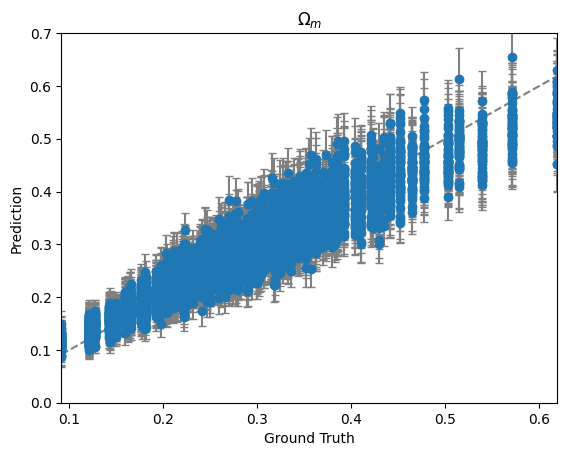

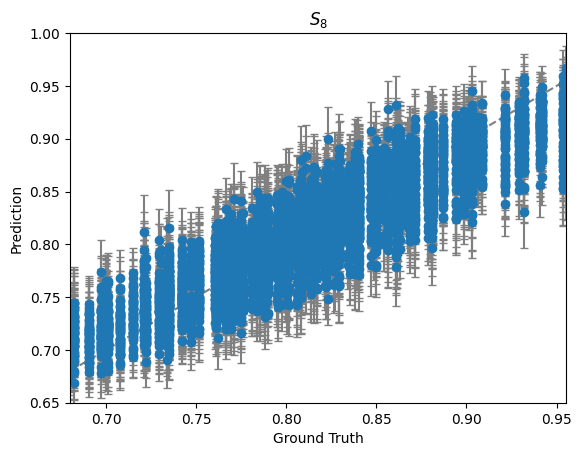

In [40]:
# Comparison of the means & standard deviations of the posterior distributions and the validation labels

plt.errorbar(y_val[:,0], mean_val[:,0], yerr=errorbar_val[:,0], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(y_val[:,0]), sorted(y_val[:,0]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(y_val[:,0]), np.max(y_val[:,0]))
plt.ylim(0, 0.7)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$\Omega_m$')
plt.show()

plt.errorbar(y_val[:,1], mean_val[:,1], yerr=errorbar_val[:,1], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(y_val[:,1]), sorted(y_val[:,1]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(y_val[:,1]), np.max(y_val[:,1]))
plt.ylim(0.65, 1)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$S_8$')
plt.show()

In [32]:
validation_score = Score._score_phase1(
    true_cosmo=y_val,
    infer_cosmo=mean_val,
    errorbar=errorbar_val
)
print('averaged score:', np.mean(validation_score))
print('averaged error bar:', np.mean(errorbar_val, 0))
print(f"Validation score saved to scoring_output/{MODEL_NAME}.json")

averaged score: 10.298225892519913
averaged error bar: [0.03524766 0.02818483]
Validation score saved to scoring_output/CNN_direct_clean_robust_longer_score_V17.json


In [33]:
# Calculate percentage error while avoiding division by zero
# Method 1: Using boolean masking to exclude zeros
non_zero_mask = y_val != 0
percentage_error_masked = np.full_like(y_val, np.nan)  # Initialize with NaN
percentage_error_masked[non_zero_mask] = (y_val[non_zero_mask] - mean_val[non_zero_mask]) / y_val[non_zero_mask] * 100

# Calculate mean percentage error (NaN values are automatically ignored)
mean_percentage_error_masked = np.nanmean(percentage_error_masked, axis=0)

print(" Boolean masking to exclude zeros:")
print(f"  Ω_m: {mean_percentage_error_masked[0]:.2f}%")
print(f"  S_8: {mean_percentage_error_masked[1]:.2f}%")
print(f"  Overall: {np.nanmean(percentage_error_masked):.2f}%")

 Boolean masking to exclude zeros:
  Ω_m: -2.20%
  S_8: -0.03%
  Overall: -1.11%


# 6 - Phase one Test inference

### Estimate the summary statistics $\boldsymbol{d}$ for all test data

In [34]:
test_dataset = CosmologyDataset(
    data=data_obj.kappa_test, 
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

In [35]:
model.eval()
means_pred_list, sigmas_pred_list = [], []
pbar = tqdm(test_loader, total=len(test_loader), desc="Inference on the test set")
with torch.no_grad():
    for X in pbar:
        X = X.to(config.DEVICE)
        means_pred, sigmas_pred = model(X)         
        means_pred_list.append(means_pred.cpu().numpy()) 
        sigmas_pred_list.append(sigmas_pred.cpu().numpy())
        
mean = np.concatenate(means_pred_list, axis=0)
mean = label_scaler.inverse_transform(mean)          # inverse transform

errorbar = np.concatenate(sigmas_pred_list, axis=0)
errorbar = errorbar*label_scaler.var_**0.5           # rescale by the training label std

Inference on the test set: 100%|██████████| 63/63 [00:03<00:00, 18.40it/s]


In [36]:
## Include the prior that the cosmological parameters are not negative
negative_mask = mean - errorbar < 0
errorbar[negative_mask] = mean[negative_mask]

In [37]:
data = {"means": mean.tolist(), "errorbars": errorbar.tolist()}
the_date = datetime.datetime.now().strftime("%y-%m-%d-%H-%M")
zip_file_name = 'Submission_' + the_date + '.zip'
zip_file = Utility.save_json_zip(
    submission_dir="submissions",
    json_file_name="result.json",
    zip_file_name=zip_file_name,
    data=data
)
print(f"Submission ZIP saved at: {zip_file}")

# Save the validation score as a JSON file
scoring_output = {"validation_score": float(validation_score),
                  "num_val": Nval,
                  "num_train": Ntrain,
                  "test_submission_file": zip_file_name}

with open(f"scoring_output/{MODEL_NAME}.json", "w") as f:
    json.dump(scoring_output, f, indent=2)

Submission ZIP saved at: submissions/Submission_25-11-15-12-12.zip
